In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "..")

from cmapss.data import load_raw


train = load_raw("FD001", "train")
train.head()


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Text(0.5, 0, 'levetid (sykluser)')

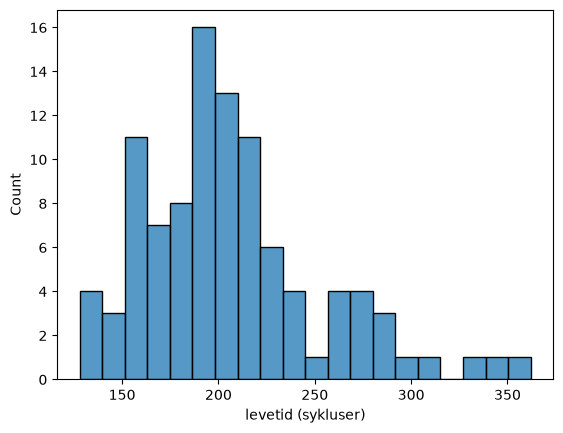

In [3]:
lifetimes = train.groupby("unit_nr").time_cycles.max()
sns.histplot(lifetimes, bins=20)
lifetimes.describe()
plt.xlabel("levetid (sykluser)")

In [4]:
train.std(numeric_only=True).sort_values()
sensors = [c for c in train.columns if c.startswith("s_")]
dead = train[sensors].std()[lambda s: s < 1e-10].index.tolist()
print(dead)
print(f"{len(dead)} døde, {len(sensors) - len(dead)} igjen")

['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
6 døde, 15 igjen


['s_1', 's_10', 's_16', 's_18', 's_19', 's_5']


<Axes: >

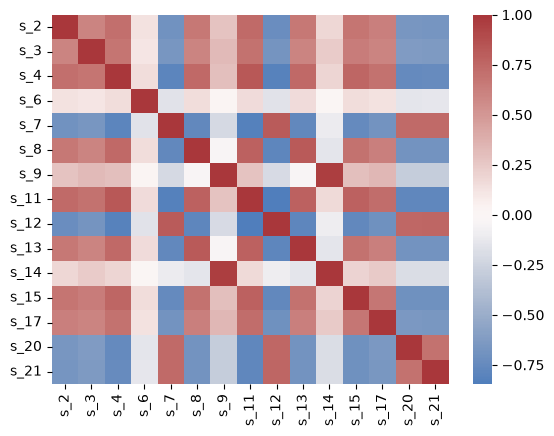

In [5]:
std = train[sensors].std()
informative = std[std > 1e-6].index.tolist()
print(sorted(set(sensors) - set(informative)))   # sjekk hva som faller ut

sns.heatmap(train[informative].corr(), cmap="vlag", center=0, annot=False)

In [6]:
subset = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_12"]   # sterkt korrelerte med slitasje
sample = train.sample(3000, random_state=42).copy()
sample["rul_bin"] = pd.qcut(sample["RUL"], 4, labels=["kritisk", "sen", "midt", "tidlig"])

sns.pairplot(sample, hue="rul_bin", vars=subset,
             palette="rocket_r", height=1.8, plot_kws={"s": 8, "alpha": 0.4})

KeyError: 'RUL'